In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import random

In [ ]:
#from google.colab import drive
#drive.mount('/content/drive')

In [ ]:
# Read all files in the directory

def read_file(in_folder, percent=1, random_selection=True):
    all_files = [f for f in sorted(os.listdir(in_folder))
                 if f.endswith('.csv')]
    num_files = int(np.floor(len(all_files) * percent))

    if random_selection:
        chosen_files = random.sample(all_files, num_files)
    else:
        chosen_files = all_files[:num_files]

    dfs = []
    for i, file in enumerate(chosen_files):
        file_path = os.path.join(in_folder, file)
        print(f"Reading {file_path}")

        try:
            temp_df = pd.read_csv(file_path, encoding='utf-8')
        except UnicodeDecodeError:
            try:
                temp_df = pd.read_csv(file_path, encoding='latin1')
            except Exception as e:
                print(f"fail to read {file_path}: {e}")
                continue

        dfs.append(temp_df)

    if not dfs:
        raise ValueError("failed")

    df = pd.concat(dfs, ignore_index=True)
    print(f" {len(dfs)} ")
    return df

In [ ]:
#path = "/content/drive/My Drive/ISE 534 All Data/"
from pathlib import Path
path = Path.home() / 'Desktop' / 'ISE 534' / 'project' / 'Data'
random.seed(28)
df = read_file(path, percent=0.15, random_selection=True)

Reading /Users/xx-g/Desktop/ISE 534/project/Data/uk_obs_coordinates_000000000073.csv
Reading /Users/xx-g/Desktop/ISE 534/project/Data/uk_obs_coordinates_000000000022.csv
Reading /Users/xx-g/Desktop/ISE 534/project/Data/uk_obs_coordinates_000000000008.csv
Reading /Users/xx-g/Desktop/ISE 534/project/Data/uk_obs_coordinates_000000000030.csv
Reading /Users/xx-g/Desktop/ISE 534/project/Data/uk_obs_coordinates_000000000059.csv
Reading /Users/xx-g/Desktop/ISE 534/project/Data/uk_obs_coordinates_000000000039.csv
Reading /Users/xx-g/Desktop/ISE 534/project/Data/uk_obs_coordinates_000000000085.csv
Reading /Users/xx-g/Desktop/ISE 534/project/Data/uk_obs_coordinates_000000000045.csv
Reading /Users/xx-g/Desktop/ISE 534/project/Data/uk_obs_coordinates_000000000021.csv
Reading /Users/xx-g/Desktop/ISE 534/project/Data/uk_obs_coordinates_000000000065.csv
Reading /Users/xx-g/Desktop/ISE 534/project/Data/uk_obs_coordinates_000000000023.csv
Reading /Users/xx-g/Desktop/ISE 534/project/Data/uk_obs_coordinat

## Data Cleaning

In [ ]:
df = df.drop_duplicates()
print(df.shape)
df = df.dropna()
print(df.shape)

(42767096, 6)
(42767096, 6)


In [ ]:
floor_count = df['Level'].value_counts().reset_index()
floor_count.columns = ['Level', 'count']

print(floor_count)

          Level     count
0  Ground Floor  15940781
1     1st Floor  13485900
2     2nd Floor  13340415


In [ ]:
#change the format of local time into datetime
df['localtime'] = df['localtime'].replace(' UTC', '', regex=False)
df['localtime'] = pd.to_datetime(df['localtime'], errors='coerce')
print(df.head())

        Site         Level      ClientMacAddr        lat       lng  \
0  UK Office  Ground Floor  a4:c3:f0:a1:fa:a4  51.460860 -0.932340   
1  UK Office  Ground Floor  90:61:ae:25:4b:2b  51.460612 -0.932391   
2  UK Office  Ground Floor  88:66:a5:0e:6c:33  51.460573 -0.932395   
3  UK Office  Ground Floor  9c:da:3e:7e:f9:14  51.460533 -0.932372   
4  UK Office  Ground Floor  28:3a:4d:27:18:73  51.460459 -0.932468   

                         localtime  
0 2020-01-03 09:47:35.290000+00:00  
1 2020-01-03 09:47:33.295000+00:00  
2 2020-01-03 09:47:30.081000+00:00  
3 2020-01-03 09:47:29.885000+00:00  
4 2020-01-03 09:47:29.586000+00:00  


In [ ]:
mac_count=pd.DataFrame(df.ClientMacAddr.value_counts())
mac_count.reset_index(level=0, inplace=True)
mac_count.columns = ['ClientMacAddr', 'count']
mac_count[:]

,ClientMacAddr,count
0,9c:8c:6e:46:1c:5e,1651198
1,9c:8c:6e:46:0b:7c,1650690
2,04:ea:56:92:f9:9b,605411
3,00:23:a7:e7:96:0c,529026
4,fc:03:9f:07:af:f4,529023
...,...,...
26651,00:0c:e7:95:18:d3,1
26652,38:80:df:ab:8d:0b,1
26653,8c:bf:a6:71:d7:fb,1
26654,80:58:f8:0b:05:db,1


In [ ]:
# Remove the the Mac IDs that appears less than 10 times(we consider the appearance less than 10 times as vistor)
ten_counts=mac_count[mac_count['count']<=10]
ten_counts=list(ten_counts['ClientMacAddr'])
df = df[~df.ClientMacAddr.isin(ten_counts)]
print(df.head())
print(df.shape)

        Site         Level      ClientMacAddr        lat       lng  \
0  UK Office  Ground Floor  a4:c3:f0:a1:fa:a4  51.460860 -0.932340   
1  UK Office  Ground Floor  90:61:ae:25:4b:2b  51.460612 -0.932391   
2  UK Office  Ground Floor  88:66:a5:0e:6c:33  51.460573 -0.932395   
3  UK Office  Ground Floor  9c:da:3e:7e:f9:14  51.460533 -0.932372   
4  UK Office  Ground Floor  28:3a:4d:27:18:73  51.460459 -0.932468   

                         localtime  
0 2020-01-03 09:47:35.290000+00:00  
1 2020-01-03 09:47:33.295000+00:00  
2 2020-01-03 09:47:30.081000+00:00  
3 2020-01-03 09:47:29.885000+00:00  
4 2020-01-03 09:47:29.586000+00:00  
(42760670, 6)


In [ ]:
# Add day_of_week and week
df['day_of_week'] = df['localtime'].dt.weekday
df['week'] = df['localtime'].dt.isocalendar().week
workday_counts = df.groupby('week')['day_of_week'].nunique()
df['workday_in_week'] = df['week'].map(workday_counts)

print(df.head())

        Site         Level      ClientMacAddr        lat       lng  \
0  UK Office  Ground Floor  a4:c3:f0:a1:fa:a4  51.460860 -0.932340   
1  UK Office  Ground Floor  90:61:ae:25:4b:2b  51.460612 -0.932391   
2  UK Office  Ground Floor  88:66:a5:0e:6c:33  51.460573 -0.932395   
3  UK Office  Ground Floor  9c:da:3e:7e:f9:14  51.460533 -0.932372   
4  UK Office  Ground Floor  28:3a:4d:27:18:73  51.460459 -0.932468   

                         localtime  day_of_week  week  workday_in_week  
0 2020-01-03 09:47:35.290000+00:00          4.0     1              7.0  
1 2020-01-03 09:47:33.295000+00:00          4.0     1              7.0  
2 2020-01-03 09:47:30.081000+00:00          4.0     1              7.0  
3 2020-01-03 09:47:29.885000+00:00          4.0     1              7.0  
4 2020-01-03 09:47:29.586000+00:00          4.0     1              7.0  


In [ ]:
# Calculate the moving speed of each MacID
df = df.sort_values(by=['ClientMacAddr', 'localtime']).copy()

df['prev_lat'] = df.groupby('ClientMacAddr')['lat'].shift(1)
df['prev_lng'] = df.groupby('ClientMacAddr')['lng'].shift(1)
df['prev_time'] = df.groupby('ClientMacAddr')['localtime'].shift(1)

df['time_diff'] = (df['localtime'] - df['prev_time']).dt.total_seconds()

def haversine_vector(lat1, lon1, lat2, lon2):
    R = 6371000  # Earth radius in meters
    lat1 = np.radians(lat1)
    lat2 = np.radians(lat2)
    dlat = lat2 - lat1
    dlon = np.radians(lon2 - lon1)

    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

df['distance_m'] = haversine_vector(
    df['prev_lat'].values,
    df['prev_lng'].values,
    df['lat'].values,
    df['lng'].values
)

df['speed_mps'] = df['distance_m'] / df['time_diff']
df['speed_mps'] = df['speed_mps'].replace([np.inf, -np.inf], 0).fillna(0)


## Data Manipulation

In [ ]:
#MacID with same lat and lng (and the work day in a week is equal to 7) are fixed facilities
mac_counts = df.groupby('ClientMacAddr')[['lat', 'lng']].nunique()
mac_with_unique_location = mac_counts[
    (mac_counts['lat'] == 1) & (mac_counts['lng'] == 1)
].index
unique_mac = df[df['ClientMacAddr'].isin(mac_with_unique_location)]
print(unique_mac)
print(len(unique_mac))


               Site         Level      ClientMacAddr        lat       lng  \
34391821  UK Office     1st Floor  00:08:22:40:d8:fb  51.460472 -0.932239   
34391637  UK Office     1st Floor  00:08:22:40:d8:fb  51.460472 -0.932239   
34391616  UK Office     1st Floor  00:08:22:40:d8:fb  51.460472 -0.932239   
34391427  UK Office     1st Floor  00:08:22:40:d8:fb  51.460472 -0.932239   
34391231  UK Office     1st Floor  00:08:22:40:d8:fb  51.460472 -0.932239   
...             ...           ...                ...        ...       ...   
30152500  UK Office  Ground Floor  fc:77:74:f1:b0:4e  51.460943 -0.932167   
30152418  UK Office  Ground Floor  fc:77:74:f1:b0:4e  51.460943 -0.932167   
30152330  UK Office  Ground Floor  fc:77:74:f1:b0:4e  51.460943 -0.932167   
30152243  UK Office  Ground Floor  fc:77:74:f1:b0:4e  51.460943 -0.932167   
30152155  UK Office  Ground Floor  fc:77:74:f1:b0:4e  51.460943 -0.932167   

                                localtime  day_of_week  week  workday_in_we

In [ ]:
#For those MacID with different lat and lng
nonunique_mac = mac_counts[mac_counts > 1].index
mac_nonunique_counts = df.groupby('ClientMacAddr')[['lat', 'lng']].nunique()
mac_nonunique_location = mac_nonunique_counts[
    (mac_nonunique_counts['lat'] != 1)|(mac_nonunique_counts['lng'] != 1)
].index
print(mac_nonunique_location)
print(len(mac_nonunique_location))
# Calculate the time differences of Mac Address
filtered_df = df[df['ClientMacAddr'].isin(mac_nonunique_location)].copy()
filtered_df = filtered_df.sort_values(by=['ClientMacAddr', 'localtime'])
filtered_df['time_diff'] = filtered_df.groupby('ClientMacAddr')['localtime'].diff().dt.total_seconds()
print(filtered_df)
# Arranged by time differences DESC
average_time_diff = filtered_df.groupby('ClientMacAddr')['time_diff'].mean().reset_index()
average_time_diff_sorted = average_time_diff.sort_values(by='time_diff', ascending=False).round(3)
print(average_time_diff_sorted)

Index(['00:00:00:00:00:00', '00:07:88:d8:94:64', '00:08:22:08:c5:fb',
       '00:08:22:20:bc:fb', '00:08:22:26:bb:fb', '00:08:22:2a:d6:ff',
       '00:08:22:36:c4:fb', '00:08:22:38:bd:fb', '00:08:22:44:bb:fb',
       '00:08:22:5a:b9:fb',
       ...
       'fc:62:b9:70:e2:a5', 'fc:62:b9:b9:4c:23', 'fc:62:b9:ba:c9:e3',
       'fc:62:b9:ea:b4:b6', 'fc:65:de:04:ba:a1', 'fc:94:35:23:ee:a5',
       'fc:94:35:24:00:a7', 'fc:a6:67:be:c0:a5', 'fc:db:b3:30:28:c9',
       'fc:db:b3:48:91:1e'],
      dtype='object', name='ClientMacAddr', length=14577)
14577
               Site         Level      ClientMacAddr        lat       lng  \
23042125  UK Office  Ground Floor  00:00:00:00:00:00  51.460593 -0.932389   
23042111  UK Office  Ground Floor  00:00:00:00:00:00  51.460728 -0.932389   
23042077  UK Office  Ground Floor  00:00:00:00:00:00  51.460728 -0.932389   
23042038  UK Office  Ground Floor  00:00:00:00:00:00  51.460728 -0.932389   
23042003  UK Office  Ground Floor  00:00:00:00:00:00  51.460728

In [ ]:
moving_speed = df.groupby('ClientMacAddr')['speed_mps'].mean().reset_index()
moving_speed_sorted = moving_speed.sort_values(by='speed_mps', ascending=False).round(3)
moving_speed_sorted = moving_speed_sorted[moving_speed_sorted['ClientMacAddr'].isin(mac_nonunique_location)]
print(moving_speed_sorted)
print(len(moving_speed_sorted))

           ClientMacAddr  speed_mps
9213   80:58:f8:0a:04:ed     11.924
7552   68:c4:4d:d6:53:73      7.403
7957   68:c4:4d:ee:6b:30      7.212
4321   68:c4:4d:1b:28:a3      5.580
11985  80:58:f8:41:2a:81      4.663
...                  ...        ...
763    0c:e7:25:91:ce:cc      0.000
13802  80:58:f8:65:04:5b      0.000
9248   80:58:f8:0a:ba:22      0.000
20622  80:58:f8:eb:79:3e      0.000
24695  e4:04:39:a2:4f:22      0.000

[14577 rows x 2 columns]
14577


In [ ]:
# We find that the normal walking speed is 1.5 m/s, so for the signals whose speed is larger than 1.5 m/s are defined as fixed facility
fixed_macs = moving_speed_sorted[moving_speed_sorted['speed_mps'] > 1.5]
print(fixed_macs)
print(len(fixed_macs))

           ClientMacAddr  speed_mps
9213   80:58:f8:0a:04:ed     11.924
7552   68:c4:4d:d6:53:73      7.403
7957   68:c4:4d:ee:6b:30      7.212
4321   68:c4:4d:1b:28:a3      5.580
11985  80:58:f8:41:2a:81      4.663
4223   68:c4:4d:16:93:45      4.165
19377  80:58:f8:d2:c6:af      3.935
5611   68:c4:4d:66:73:ee      3.933
7862   68:c4:4d:e8:9c:61      3.845
7014   68:c4:4d:b8:6c:31      3.390
15215  80:58:f8:7f:e7:bd      2.898
13611  80:58:f8:61:5b:fa      2.824
5084   68:c4:4d:48:b0:75      2.815
24120  d0:77:14:6a:70:b5      2.729
15501  80:58:f8:85:ed:b0      2.388
2392   24:46:c8:ea:7e:54      2.374
477    00:bb:3a:83:e1:23      2.291
17385  80:58:f8:ab:81:d8      2.188
11444  80:58:f8:36:e6:4e      2.168
18478  80:58:f8:c0:e0:37      2.086
20987  80:58:f8:f2:a4:fb      2.080
17433  80:58:f8:ac:60:5a      2.072
2384   24:46:c8:e7:b4:f8      2.046
4196   68:c4:4d:15:24:9f      2.039
12385  80:58:f8:48:fa:bf      1.977
5864   68:c4:4d:75:60:25      1.903
22048  88:b4:a6:2f:d4:40    

In [ ]:
# Merged the data
unique_mac_data = unique_mac[['ClientMacAddr', 'lat', 'lng','Level','speed_mps']].drop_duplicates()
fixed_mac_data = df[df['ClientMacAddr'].isin(fixed_macs['ClientMacAddr'])][['ClientMacAddr', 'lat', 'lng','Level','speed_mps']].drop_duplicates()
merged_df = pd.concat([unique_mac_data, fixed_mac_data], ignore_index=True)
print(len(fixed_mac_data))
print(merged_df.sort_values(by = ['speed_mps'], ascending = False))
print(len(merged_df))

1321
           ClientMacAddr        lat       lng         Level   speed_mps
10835  80:58:f8:08:de:fe  51.460568 -0.932414  Ground Floor  185.595090
10788  68:c4:4d:e7:9b:f2  51.460510 -0.932420     2nd Floor  179.388522
10840  80:58:f8:0a:04:ed  51.460718 -0.932396  Ground Floor  164.972705
11203  9c:da:3e:7f:e3:a1  51.460506 -0.932426     2nd Floor  132.858067
11788  e0:5f:45:99:d9:8d  51.460573 -0.932296     2nd Floor   96.889695
...                  ...        ...       ...           ...         ...
4017   80:58:f8:15:42:bd  51.460938 -0.932382  Ground Floor    0.000000
4018   80:58:f8:15:46:1c  51.460786 -0.932225  Ground Floor    0.000000
4019   80:58:f8:15:68:07  51.460943 -0.932167  Ground Floor    0.000000
4020   80:58:f8:15:6c:68  51.460655 -0.932239  Ground Floor    0.000000
6024   80:58:f8:69:94:b4  51.460928 -0.932383  Ground Floor    0.000000

[12048 rows x 5 columns]
12048


Text(0.5, 1.0, 'Fixed Devices by Floor Level')

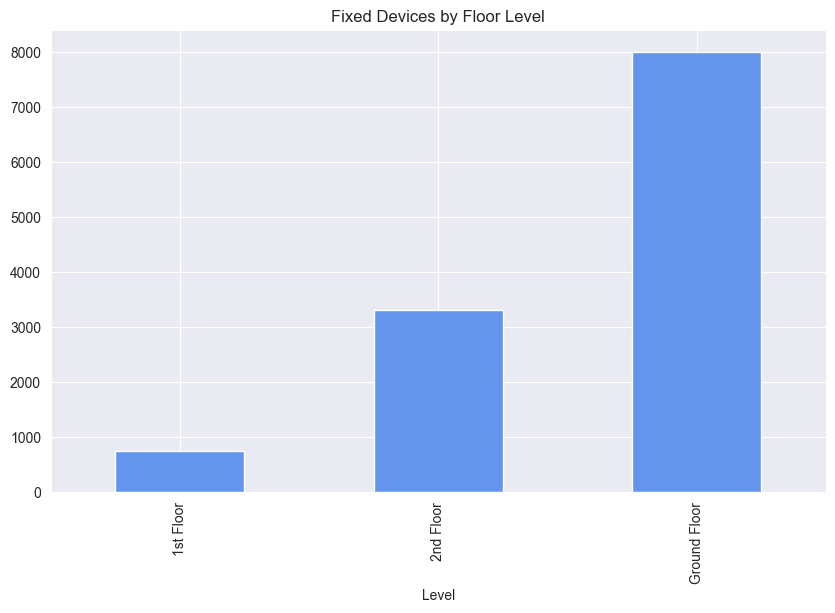

In [ ]:
#The distribution of fixed devices in each floor
plt.figure(figsize=(10, 6))
merged_df['Level'].value_counts().sort_index().plot(kind='bar', color='cornflowerblue')
plt.title('Fixed Devices by Floor Level')

In [ ]:
# We randomly choose 50 fixed devices and assign the Emergency Level based on the temperature and pressure as our external data
np.random.seed(0)
selected_macs = merged_df.sample(n=50, random_state=42).reset_index(drop=True)

def simulate_temp():
    prob = np.random.rand()
    if prob < 0.80:
        return np.random.normal(25, 2)
    elif prob < 0.90:
        return np.random.normal(32, 1)
    else:
        return np.random.normal(38, 1.5)

def simulate_pressure():
    prob = np.random.rand()
    if prob < 0.90:
        return np.random.normal(1.5, 0.2)
    elif prob < 0.95:
        return np.random.normal(2.1, 0.1)
    else:
        return np.random.normal(2.7, 0.2)

selected_macs["temperature"] = [simulate_temp() for _ in range(len(selected_macs))]
selected_macs["pressure"] = [simulate_pressure() for _ in range(len(selected_macs))]

def classify_leak(temp, pressure):
    if temp > 35 or pressure > 2.5:
        return "3"
    elif temp > 30 or pressure > 2.0:
        return "2"
    else:
        return "1"

selected_macs["EmergencyLevel"] = selected_macs.apply(
    lambda row: classify_leak(row["temperature"], row["pressure"]),
    axis=1
)

df_simulated = selected_macs[['ClientMacAddr', 'lat', 'lng', 'Level', 'temperature', 'pressure', 'EmergencyLevel']]
print(df_simulated)
print(df_simulated['EmergencyLevel'].value_counts())

        ClientMacAddr        lat       lng         Level  temperature  \
0   80:58:f8:aa:a6:d9  51.460924 -0.932383  Ground Floor    26.483183   
1   68:c4:4d:b8:35:1e  51.460801 -0.932380     2nd Floor    28.105827   
2   e4:04:39:2d:3d:08  51.460914 -0.932186     1st Floor    23.314552   
3   80:58:f8:84:01:a0  51.460856 -0.932362  Ground Floor    33.969924   
4   80:58:f8:f2:d9:78  51.460943 -0.932167  Ground Floor    39.899178   
5   68:c4:4d:ca:b5:67  51.460801 -0.932380     2nd Floor    23.988247   
6   24:46:c8:c2:2c:51  51.460718 -0.932396  Ground Floor    25.968624   
7   9c:f4:8e:e3:c1:3f  51.460775 -0.932322     1st Floor    32.579140   
8   68:c4:4d:be:3b:a5  51.460900 -0.932418     2nd Floor    37.727626   
9   68:c4:4d:ba:a5:fc  51.460801 -0.932380     2nd Floor    27.820409   
10  80:58:f8:ab:a7:a3  51.460718 -0.932396  Ground Floor    23.078491   
11  80:58:f8:b5:9e:50  51.460943 -0.932167  Ground Floor    38.565390   
12  1c:e1:92:72:7b:08  51.460376 -0.932994     2nd 

### Visualization

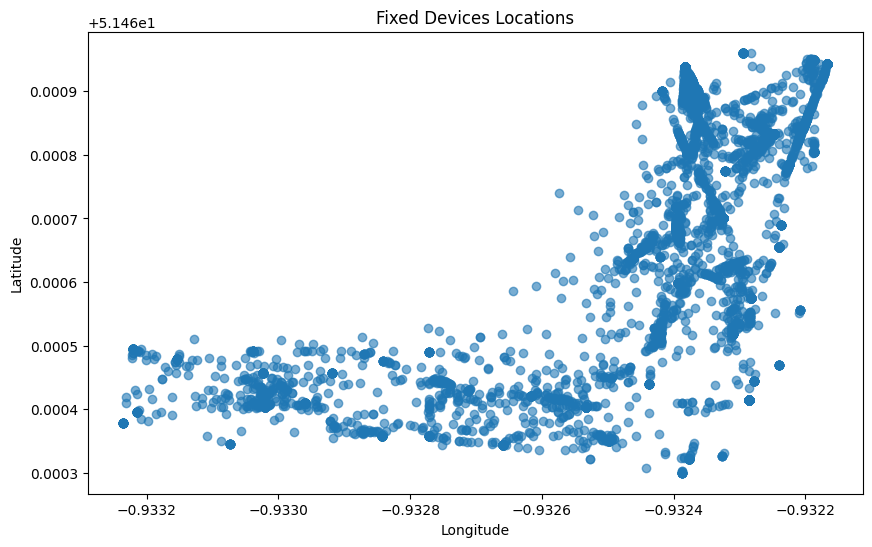

In [ ]:
#Distribution of fixed devices
plt.figure(figsize=(10, 6))
plt.scatter(merged_df['lng'], merged_df['lat'], alpha=0.6)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Fixed Devices Locations')
plt.show()

4485


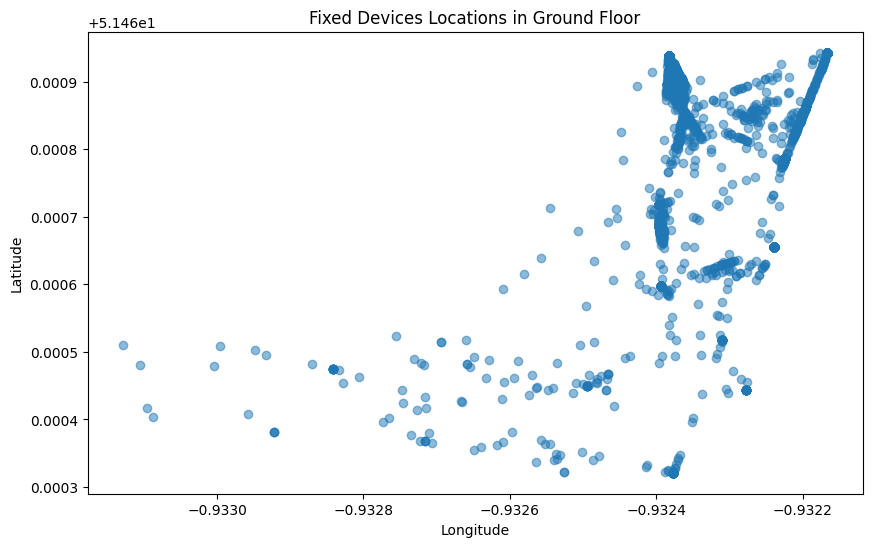

In [ ]:
#Ditribution of fixed devices in ground floor
plt.figure(figsize=(10, 6))
ground_floor_df = merged_df[merged_df['Level'] == 'Ground Floor']
print(len(ground_floor_df))
plt.scatter(ground_floor_df['lng'], ground_floor_df['lat'], alpha=0.5)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Fixed Devices Locations in Ground Floor')
plt.show()

1244


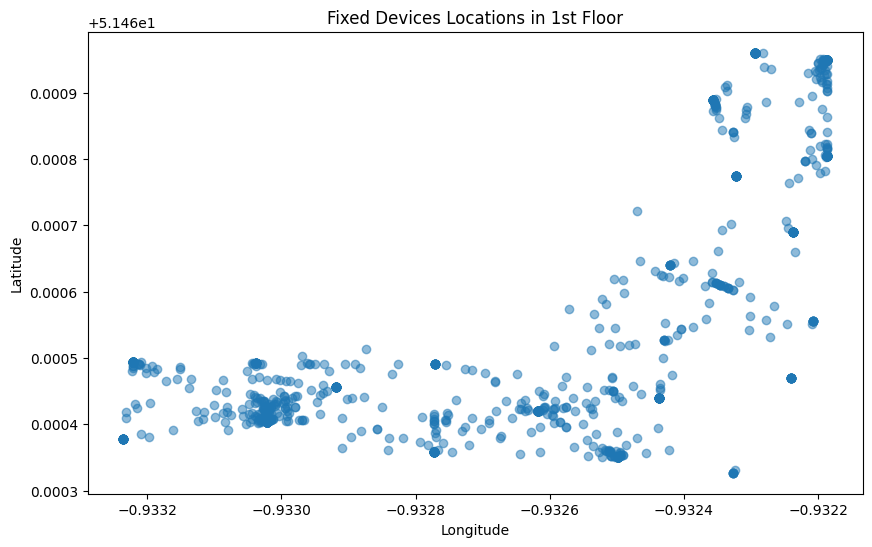

In [ ]:
#Ditribution of fixed devices in 1st floor
plt.figure(figsize=(10, 6))
first_floor_df = merged_df[merged_df['Level'] == '1st Floor']
print(len(first_floor_df))
plt.scatter(first_floor_df['lng'], first_floor_df['lat'], alpha=0.5)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Fixed Devices Locations in 1st Floor')
plt.show()

2864


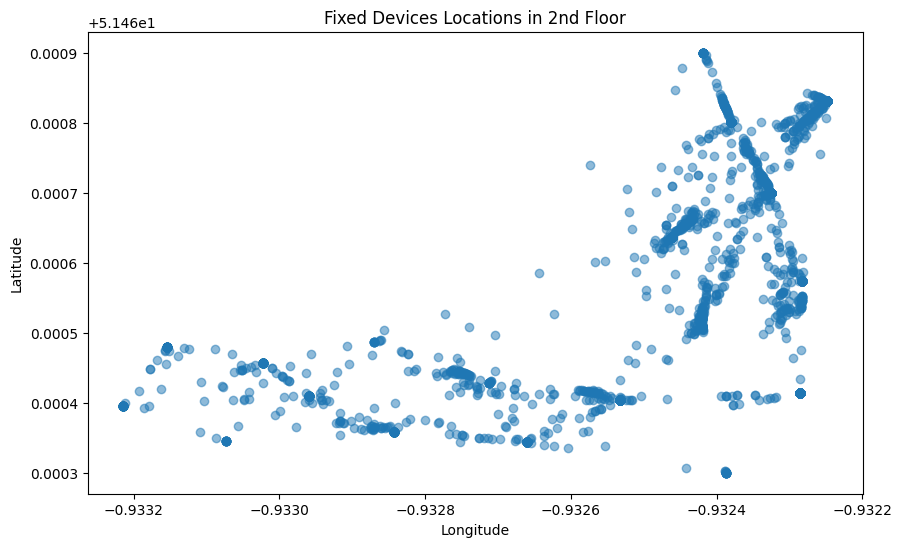

In [ ]:
#Ditribution of fixed devices in 2nd floor
plt.figure(figsize=(10, 6))
second_floor_df = merged_df[merged_df['Level'] == '2nd Floor']
print(len(second_floor_df))
plt.scatter(second_floor_df['lng'], second_floor_df['lat'], alpha=0.5)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Fixed Devices Locations in 2nd Floor')
plt.show()

### Modeling

In [ ]:
# extract 10 columns in the mobile devices in the second floor randomly, and define the job role of those 10 people
mobile = df[~df['ClientMacAddr'].isin(merged_df['ClientMacAddr'])]
print(len(mobile))

emp = mobile.sample(n=10,random_state=0)
print(emp)

42618906
               Site         Level      ClientMacAddr        lat       lng  \
13744242  UK Office     2nd Floor  cc:44:63:14:0a:7a  51.460644 -0.932456   
20270395  UK Office     2nd Floor  a4:c3:f0:a5:f1:4f  51.460436 -0.932900   
14833781  UK Office  Ground Floor  ec:ad:b8:7d:23:e8  51.460369 -0.932553   
4752253   UK Office     1st Floor  98:10:e8:3a:74:b1  51.460565 -0.932250   
15040484  UK Office  Ground Floor  f0:76:6f:79:ea:44  51.460746 -0.932325   
15521284  UK Office  Ground Floor  28:16:ad:17:e3:14  51.460496 -0.932395   
36725602  UK Office     2nd Floor  9c:da:3e:7f:a0:ee  51.460609 -0.932382   
21151228  UK Office  Ground Floor  04:ea:56:92:f9:9b  51.460361 -0.932538   
34854830  UK Office     1st Floor  8c:8e:f2:07:e2:3f  51.460493 -0.933057   
24903612  UK Office  Ground Floor  28:16:ad:17:e3:14  51.460543 -0.932328   

                                localtime  day_of_week  week  workday_in_week  \
13744242 2020-01-07 10:10:45.236000+00:00          1.0     2  

In [ ]:
emp_names = ["Alex Johnson", "Jamie Lee", "Taylor Smith", "Jordan Parker", "Morgan Davis","Casey Adams", "Drew Thompson", "Riley Morgan", "Skyler Clark", "Quinn Allen"]

roles = ["Pipeline Technician", "Safety Officer", "Leak Inspector","Supervisor"]

emp["Name"] = random.sample(emp_names, k=10)
emp["Role"] = random.choices(roles, k=10)

emp["Level"] = emp["Level"]

print(emp[['ClientMacAddr', 'Name', 'Role', 'Level','lat','lng']])

              ClientMacAddr           Name                 Role         Level  \
13744242  cc:44:63:14:0a:7a   Riley Morgan       Leak Inspector     2nd Floor   
20270395  a4:c3:f0:a5:f1:4f   Alex Johnson           Supervisor     2nd Floor   
14833781  ec:ad:b8:7d:23:e8    Casey Adams       Leak Inspector  Ground Floor   
4752253   98:10:e8:3a:74:b1   Morgan Davis       Safety Officer     1st Floor   
15040484  f0:76:6f:79:ea:44  Drew Thompson       Leak Inspector  Ground Floor   
15521284  28:16:ad:17:e3:14   Skyler Clark           Supervisor  Ground Floor   
36725602  9c:da:3e:7f:a0:ee    Quinn Allen           Supervisor     2nd Floor   
21151228  04:ea:56:92:f9:9b  Jordan Parker  Pipeline Technician  Ground Floor   
34854830  8c:8e:f2:07:e2:3f      Jamie Lee       Safety Officer     1st Floor   
24903612  28:16:ad:17:e3:14   Taylor Smith  Pipeline Technician  Ground Floor   

                lat       lng  
13744242  51.460644 -0.932456  
20270395  51.460436 -0.932900  
14833781  51

In [ ]:
# Assign the nearest worker to the fixed devices that in Emergency Level 3
level3_devices = df_simulated[df_simulated['EmergencyLevel'] == '3']
assignments = []
for idx, device in level3_devices.iterrows():

    workers_same_floor = emp[emp['Level'] == device['Level']]

    if workers_same_floor.empty:
        continue

    workers_same_floor = workers_same_floor.copy()

    workers_same_floor['distance'] = (
        abs(workers_same_floor['lat'] - device['lat']) +
        abs(workers_same_floor['lng'] - device['lng'])
    )
    nearest_worker = workers_same_floor.loc[workers_same_floor['distance'].idxmin()]

    assignments.append({
        'DeviceMacAddr': device['ClientMacAddr'],
        'Device_lat': device['lat'],
        'Device_lng': device['lng'],
        'Device_level': device['Level'],
        'worker_name': nearest_worker['Name'],
        'worker_lat': nearest_worker['lat'],
        'worker_lng': nearest_worker['lng'],
        'worker_level': nearest_worker['Level'],
        'distance': nearest_worker['distance']
    })

assignment_df = pd.DataFrame(assignments)

print(f"\nAssignment Completed! Total Assignments: {len(assignment_df)}")
print(assignment_df)


Assignment Completed! Total Assignments: 6
       DeviceMacAddr  Device_lat  Device_lng  Device_level    worker_name  \
0  80:58:f8:f2:d9:78   51.460943   -0.932167  Ground Floor  Drew Thompson   
1  68:c4:4d:be:3b:a5   51.460900   -0.932418     2nd Floor   Riley Morgan   
2  80:58:f8:b5:9e:50   51.460943   -0.932167  Ground Floor  Drew Thompson   
3  80:58:f8:ba:eb:0b   51.460943   -0.932167  Ground Floor  Drew Thompson   
4  68:c4:4d:53:86:b9   51.460801   -0.932380     2nd Floor    Quinn Allen   
5  24:46:c8:5c:0e:90   51.460438   -0.932338     1st Floor   Morgan Davis   

   worker_lat  worker_lng  worker_level  distance  
0   51.460746   -0.932325  Ground Floor  0.000356  
1   51.460644   -0.932456     2nd Floor  0.000294  
2   51.460746   -0.932325  Ground Floor  0.000356  
3   51.460746   -0.932325  Ground Floor  0.000356  
4   51.460609   -0.932382     2nd Floor  0.000195  
5   51.460565   -0.932250     1st Floor  0.000215  


In [ ]:
# Calculate each workers' distance to device
level3_devices = df_simulated[df_simulated['EmergencyLevel'] == '3']

all_distances = []

for idx, device in level3_devices.iterrows():

    workers_same_floor = emp[emp['Level'] == device['Level']]

    if workers_same_floor.empty:
        continue

    workers_same_floor = workers_same_floor.copy()

    workers_same_floor['distance'] = (
            abs(workers_same_floor['lat'] - device['lat']) +
            abs(workers_same_floor['lng'] - device['lng'])
    )


    for _, worker in workers_same_floor.iterrows():
        all_distances.append({
            'DeviceMacAddr': device['ClientMacAddr'],
            'Device_lat': device['lat'],
            'Device_lng': device['lng'],
            'Device_level': device['Level'],
            'WorkerName': worker['Name'],
            'Worker_lat': worker['lat'],
            'Worker_lng': worker['lng'],
            'Worker_level': worker['Level'],
            'Distance': worker['distance']
        })


device_worker_distance_df = pd.DataFrame(all_distances)

print(f"\nDistance calculation completed! Total records: {len(device_worker_distance_df)}")
print(device_worker_distance_df)


Distance calculation completed! Total records: 23
        DeviceMacAddr  Device_lat  Device_lng  Device_level     WorkerName  \
0   80:58:f8:f2:d9:78   51.460943   -0.932167  Ground Floor    Casey Adams   
1   80:58:f8:f2:d9:78   51.460943   -0.932167  Ground Floor  Drew Thompson   
2   80:58:f8:f2:d9:78   51.460943   -0.932167  Ground Floor   Skyler Clark   
3   80:58:f8:f2:d9:78   51.460943   -0.932167  Ground Floor  Jordan Parker   
4   80:58:f8:f2:d9:78   51.460943   -0.932167  Ground Floor   Taylor Smith   
5   68:c4:4d:be:3b:a5   51.460900   -0.932418     2nd Floor   Riley Morgan   
6   68:c4:4d:be:3b:a5   51.460900   -0.932418     2nd Floor   Alex Johnson   
7   68:c4:4d:be:3b:a5   51.460900   -0.932418     2nd Floor    Quinn Allen   
8   80:58:f8:b5:9e:50   51.460943   -0.932167  Ground Floor    Casey Adams   
9   80:58:f8:b5:9e:50   51.460943   -0.932167  Ground Floor  Drew Thompson   
10  80:58:f8:b5:9e:50   51.460943   -0.932167  Ground Floor   Skyler Clark   
11  80:58:f8:

In [ ]:
device_assigned_1 = device_worker_distance_df[device_worker_distance_df['DeviceMacAddr']=='80:58:f8:f2:d9:78']
print(device_assigned_1)

       DeviceMacAddr  Device_lat  Device_lng  Device_level     WorkerName  \
0  80:58:f8:f2:d9:78   51.460943   -0.932167  Ground Floor    Casey Adams   
1  80:58:f8:f2:d9:78   51.460943   -0.932167  Ground Floor  Drew Thompson   
2  80:58:f8:f2:d9:78   51.460943   -0.932167  Ground Floor   Skyler Clark   
3  80:58:f8:f2:d9:78   51.460943   -0.932167  Ground Floor  Jordan Parker   
4  80:58:f8:f2:d9:78   51.460943   -0.932167  Ground Floor   Taylor Smith   

   Worker_lat  Worker_lng  Worker_level  Distance  
0   51.460369   -0.932553  Ground Floor  0.000960  
1   51.460746   -0.932325  Ground Floor  0.000356  
2   51.460496   -0.932395  Ground Floor  0.000676  
3   51.460361   -0.932538  Ground Floor  0.000953  
4   51.460543   -0.932328  Ground Floor  0.000562  


In [ ]:
device_assigned_2 = device_worker_distance_df[device_worker_distance_df['DeviceMacAddr']=='68:c4:4d:be:3b:a5']
print(device_assigned_2)

       DeviceMacAddr  Device_lat  Device_lng Device_level    WorkerName  \
5  68:c4:4d:be:3b:a5     51.4609   -0.932418    2nd Floor  Riley Morgan   
6  68:c4:4d:be:3b:a5     51.4609   -0.932418    2nd Floor  Alex Johnson   
7  68:c4:4d:be:3b:a5     51.4609   -0.932418    2nd Floor   Quinn Allen   

   Worker_lat  Worker_lng Worker_level  Distance  
5   51.460644   -0.932456    2nd Floor  0.000294  
6   51.460436   -0.932900    2nd Floor  0.000946  
7   51.460609   -0.932382    2nd Floor  0.000327  


In [ ]:
print(df['lng'].min(), df['lng'].max())
print(df['lat'].min(), df['lat'].max())

-0.93323648 -0.9321665
51.46030032 51.46096035


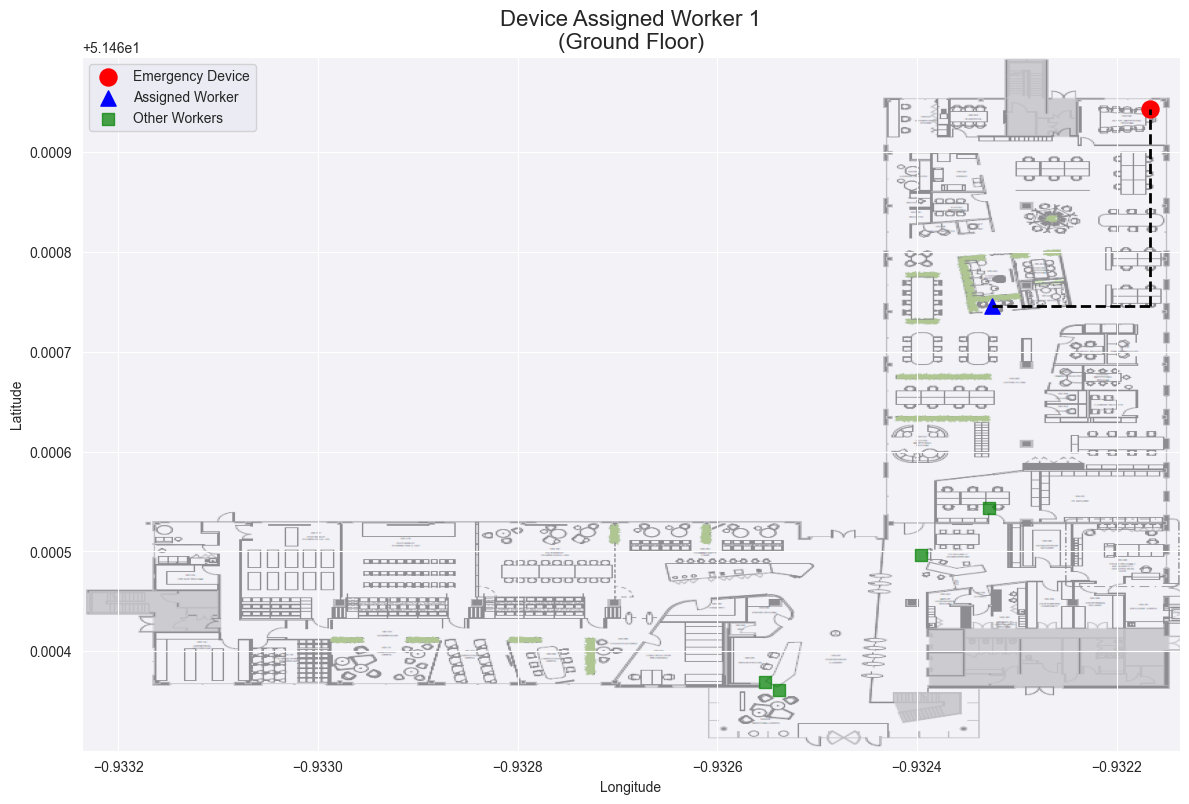

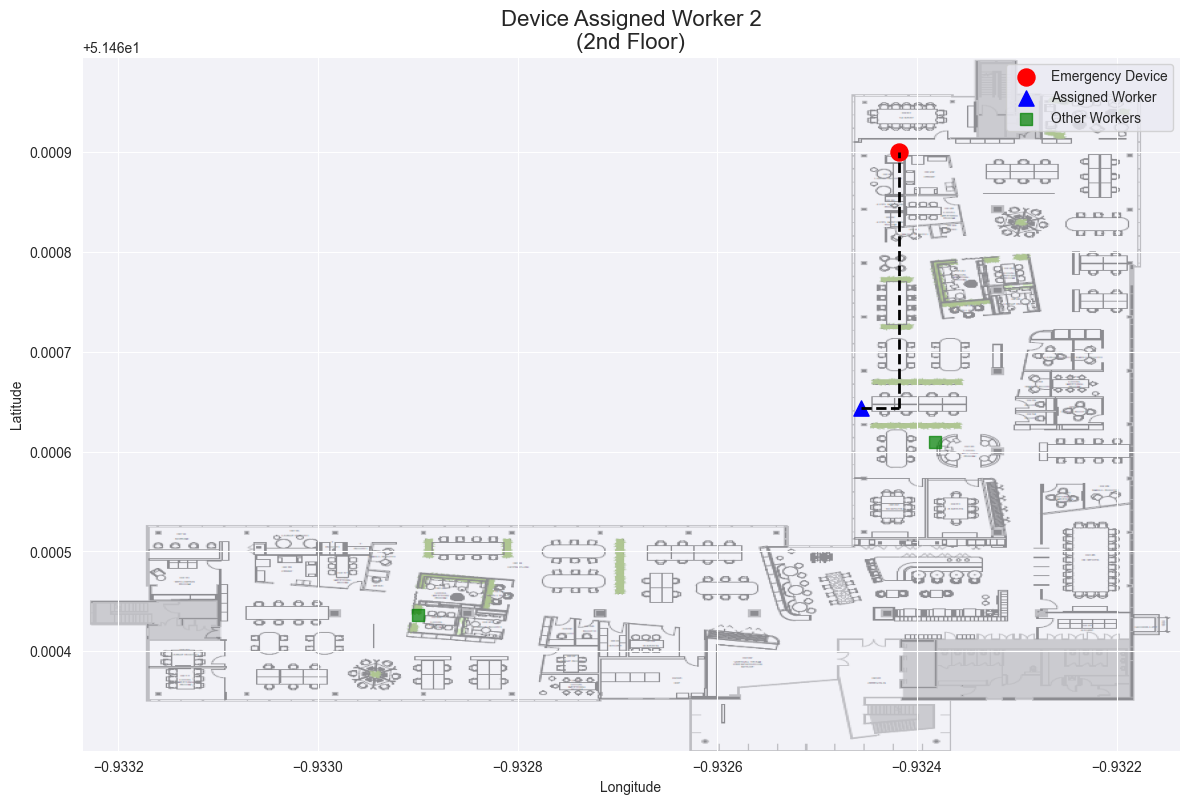

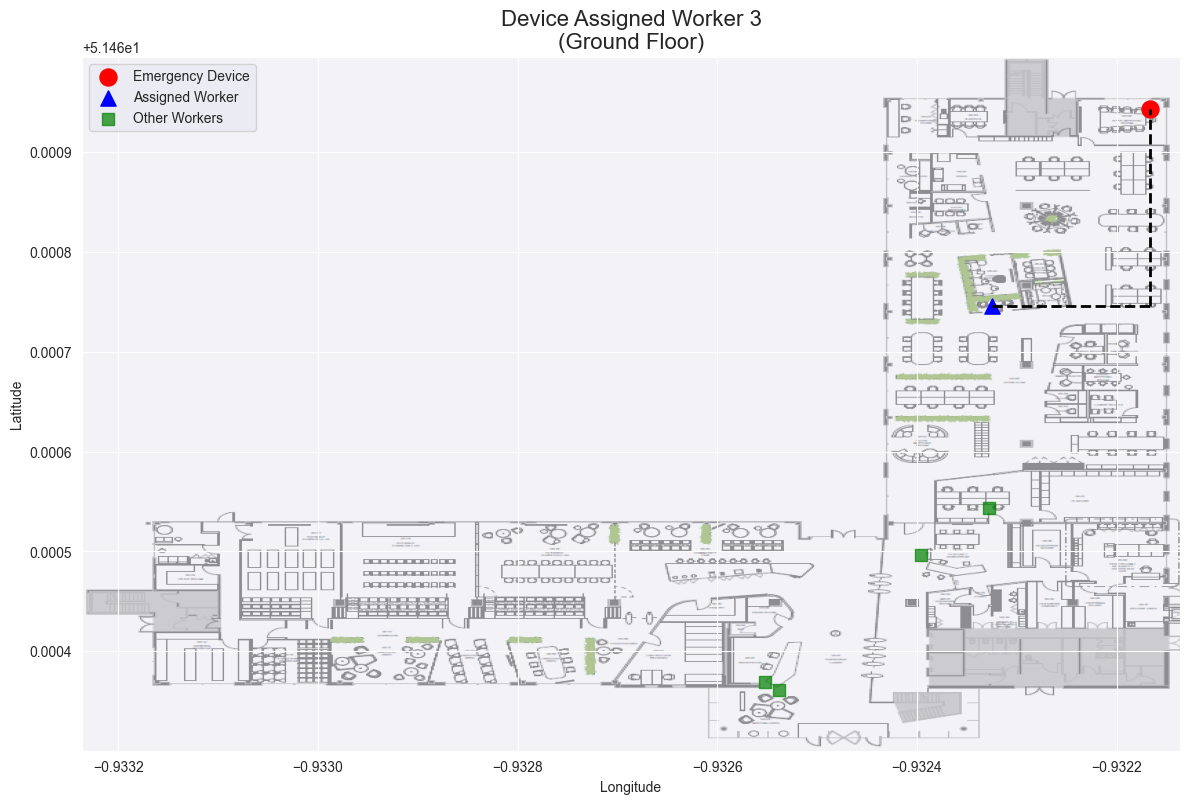

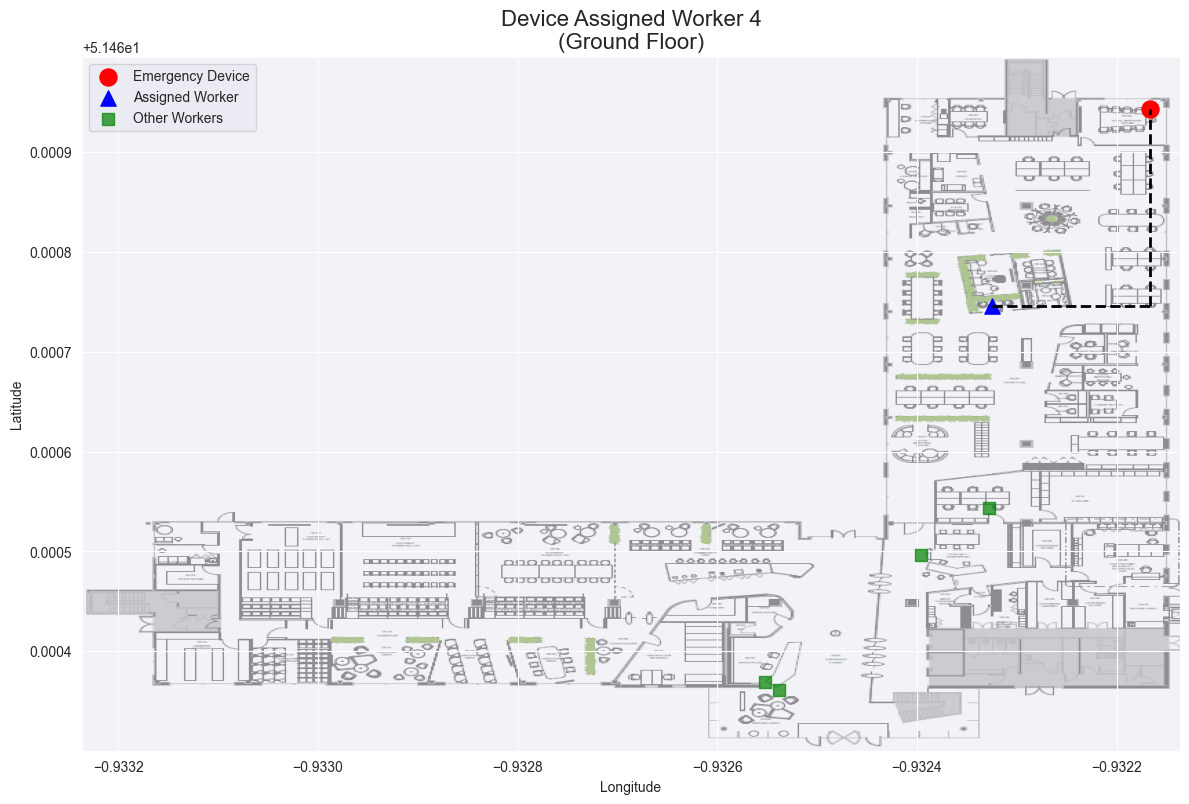

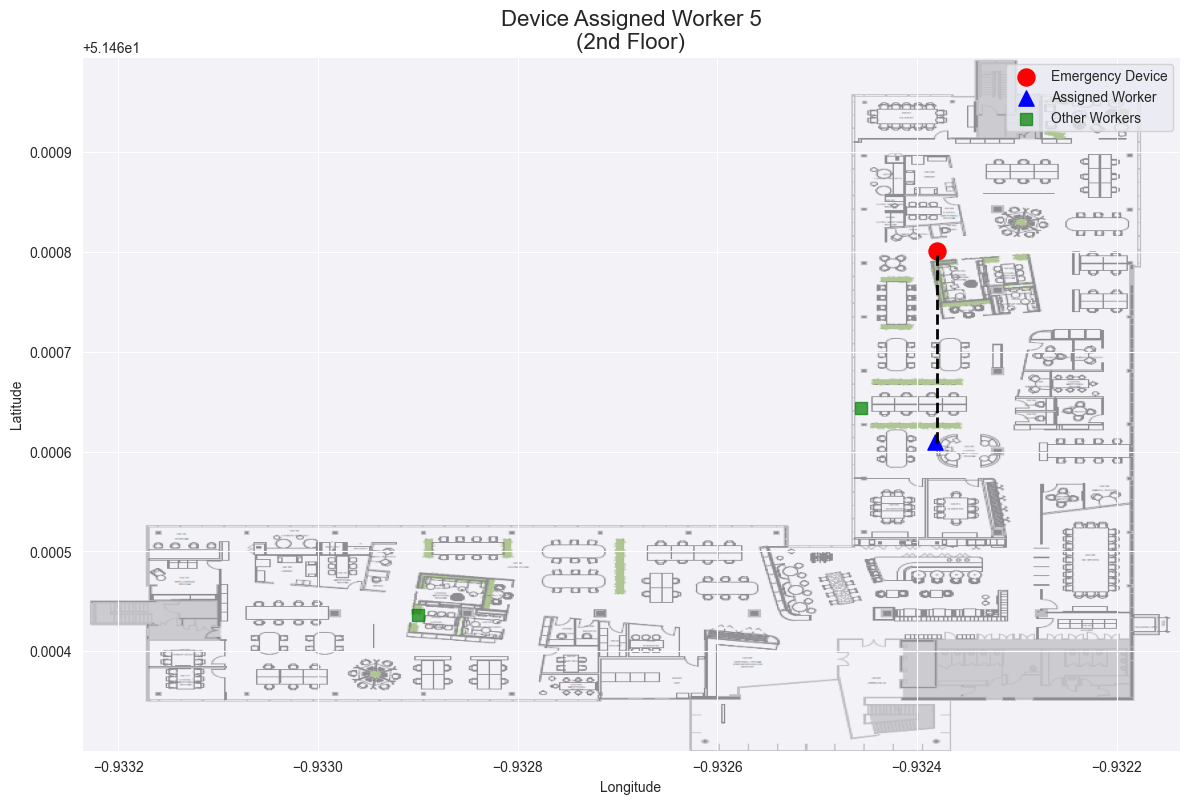

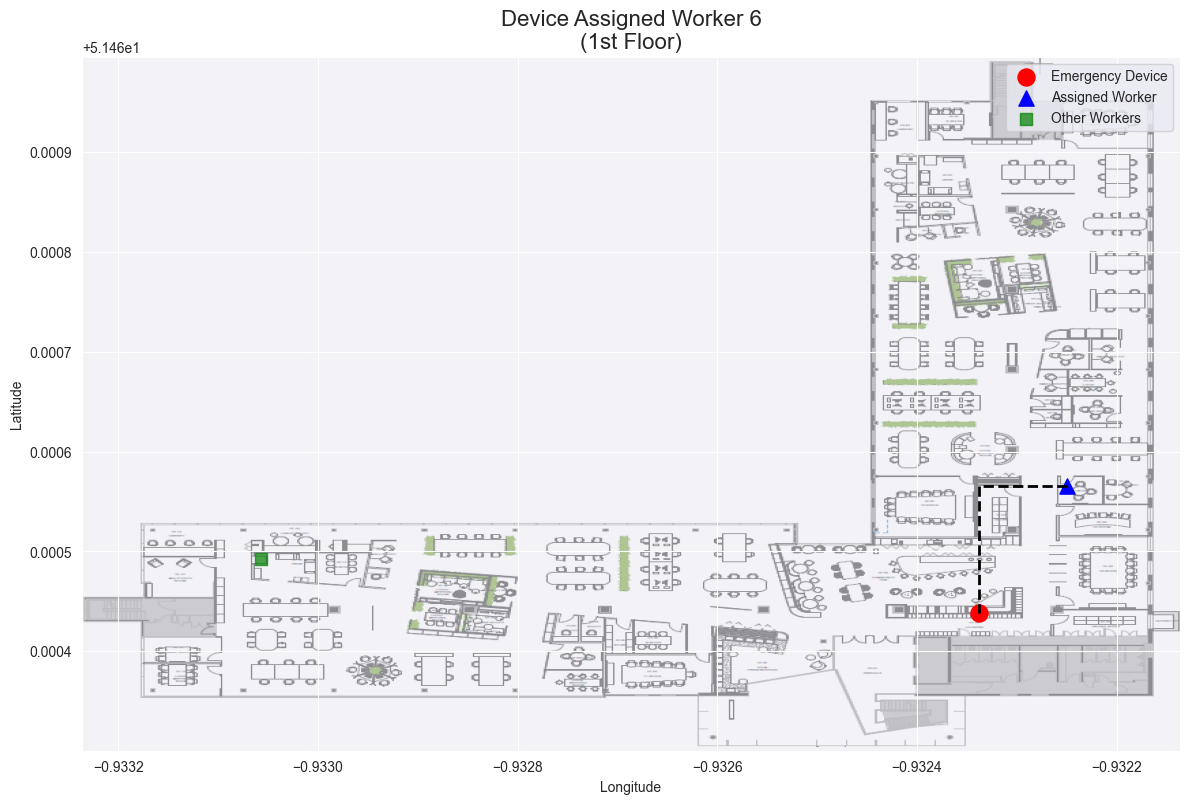

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

floor_map_paths = {
    'Ground Floor': 'first floor.png',
    '1st Floor': 'second floor.png',
    '2nd Floor': 'third floor.png'
}

floor_extent = [-0.93323648, -0.9321365, 51.46030032, 51.46099535]

for idx, row in assignment_df.iterrows():
    floor = row['Device_level']
    device_lat = row['Device_lat']
    device_lng = row['Device_lng']
    worker_lat = row['worker_lat']
    worker_lng = row['worker_lng']

    floor_workers = emp[emp['Level'] == floor]

    plt.figure(figsize=(12, 8))

    img_path = floor_map_paths.get(floor, None)
    if img_path:
        img = mpimg.imread(img_path)
        plt.imshow(img, extent=floor_extent, alpha=0.4)

    plt.scatter(device_lng, device_lat, color='red', s=150, marker='o', label='Emergency Device')

    plt.scatter(worker_lng, worker_lat, color='blue', s=120, marker='^', label='Assigned Worker')

    other_workers = floor_workers[
        (floor_workers['Name'] != row['worker_name'])
    ]
    plt.scatter(other_workers['lng'], other_workers['lat'],
                color='green', s=80, marker='s', alpha=0.7, label='Other Workers')

    plt.plot([worker_lng, device_lng], [worker_lat, worker_lat], 'k--', linewidth=2)
    plt.plot([device_lng, device_lng], [worker_lat, device_lat], 'k--', linewidth=2)

    plt.title(f'Device Assigned Worker {idx+1}\n({floor})', fontsize=16)
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.grid(True)
    plt.legend()

    plt.xlim(floor_extent[0], floor_extent[1])
    plt.ylim(floor_extent[2], floor_extent[3])

    plt.tight_layout()
    plt.show()